# 4.데이터분석_이변량_범주(숫자) vs 범주

## 4.1.환경준비

**1) 라이브러리 불러오기**

In [35]:
import pandas as pd
import numpy as np
import random as rd

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic      #mosaic plot!

import scipy.stats as spst

**1) 데이터 불러오기**
- 타이타닉 생존자 : titanic.csv  


In [36]:
titanic = pd.read_csv('./../00_data/titanic_train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [37]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [38]:
def extract_title(name):
  if 'Mr.' in name:
    return 'Mr'
  elif 'Mrs.' in name:
    return 'Mrs'
  elif 'Miss.' in name:
    return 'Miss'
  elif 'Master' in name:
    return 'Master'
  else:
    return 'Others'

# Title 열 추가
titanic['Title'] = titanic['Name'].apply(extract_title)

# 결과 확인
titanic.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs


In [39]:
titanic['Title'].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Others     27
Name: count, dtype: int64

## 4.2.범주 --> 범주

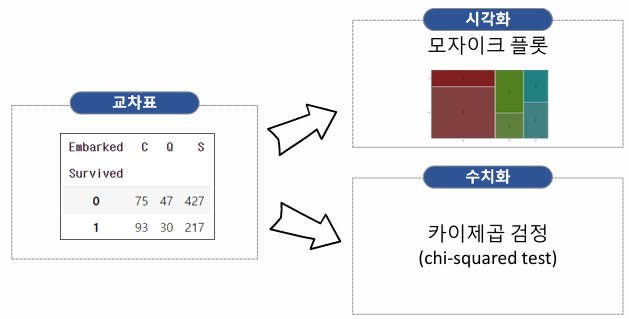

### 4.2.1. 교차표(pd.crosstab)

- 범주 vs 범주 를 비교하고 분석하기 위해서는 먼저 **교차표**를 만들어야 한다.

- pd.crosstab(행, 열)

In [ ]:
pd.crosstab(titanic['Survived'], titanic['Sex'])

Sex,female,male
Survived,,
0,81,468
1,233,109


- `pd.crosstab(행, 열, normalize =   )`
    - normalize: 비율로 계산
    - 행 기준: 각 범주 내 분포를 분석할 때 유용
    - 열 기준: 변수 간 비교를 통해 특정 범주 내 다른 변수의 비율을 볼 때 유용


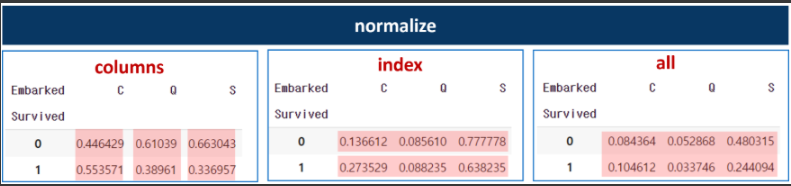

In [41]:
# 컬럼(열)을 기준으로 합했을 때
pd.crosstab(titanic['Survived'], titanic['Sex'], normalize='columns')

Sex,female,male
Survived,,
0,0.257962,0.811092
1,0.742038,0.188908


In [42]:
# 인덱스(행)을 기준으로 합했을 때
pd.crosstab(titanic['Survived'], titanic['Sex'], normalize='index')

Sex,female,male
Survived,,
0,0.147541,0.852459
1,0.681287,0.318713


In [43]:
# 전체을 기준으로 합했을 때
pd.crosstab(titanic['Survived'], titanic['Sex'], normalize='all')

Sex,female,male
Survived,,
0,0.090909,0.525253
1,0.261504,0.122334


### 4.2.2. 시각화
- mosaic
- 100% Stacked Bar


1) Pclass --> Survived

- mosaic plot
    - `mosaic(dataframe, [ feature, target])`
    - 범주형 변수 간의 비율과 분포를 시각적으로 나타내는 그래프
    - 교차표의 형태를 그림으로 표현하며, 각 사각형의 크기와 길이는 데이터의 비율을 나타냄

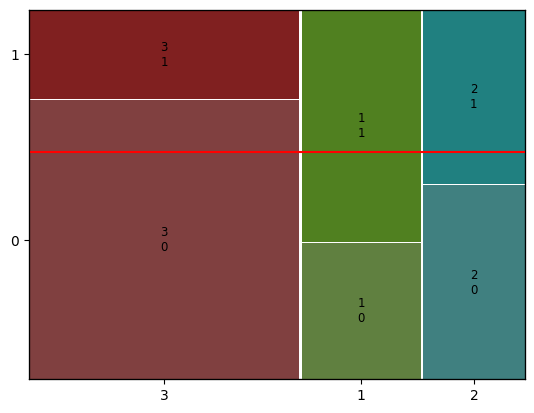

In [44]:
mosaic(titanic, ['Pclass','Survived'])

# 빨간선은 전체 평균을 의미
plt.axhline(1-titanic['Survived'].mean(), color='r') # 전체 사망률

plt.show()

① X축 길이는 각 객실등급별 승객비율을 나타낸다.

② 그 중 3등급 객실에 대해서 보면, y축의 길이는, 3등급 객실 승객 중에서 사망, 생존 비율을 의미한다.

- 100% Stacked Bar
    - 먼저 crosstab으로 집계 : `pd.crosstab(feature, target, normalize = 'index')`
    - `.plot.bar(stacked = true)`
    - 전체 평균선 : `plt.axhline()`

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


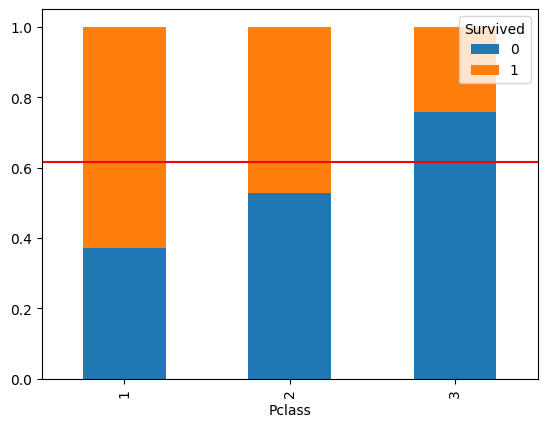

In [45]:
# 0 -> 사망자
# 3등석 -> 사람이 많다.

temp = pd.crosstab(titanic['Pclass'], titanic['Survived'], normalize='index')

display(temp)

print('='*8)

temp.plot.bar(stacked=True)
plt.axhline(1-titanic['Survived'].mean(), color='r') # 전체 사망률

plt.show()

In [46]:
# 파란색이 많을수록 죽은사람이 많다,
# 평균보다 높은지 낮은지 알수잇다.

# mosaic -> 전체 비율을 볼수있음
# 막대기 -> 몇명이 탓는지의 비율까지 알수 있음

- 비율만 비교하므로 양에 대한 비교는 할 수 없다!

**<연습문제>**

- 아래 관계에 대해서 교차표와 시각화(mosaic)를 수행하고, feature와 target 간에 관계가 있는지 분석해 봅시다.


In [47]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


[문1] Sex --> Survived

In [48]:
pd.crosstab(titanic['Survived'], titanic['Sex'])
# pd.crosstab(titanic['Sex'], titanic['Survived'])

# def makeSex(sex):
#   if sex == 'female':
#     return 1
#   else:
#     return 0
# titanic['Sex_Num'] = titanic['Sex'].apply(makeSex)

# titanic.head()

Sex,female,male
Survived,,
0,81,468
1,233,109


In [49]:
pd.crosstab(titanic['Survived'], titanic['Sex'], normalize = 'columns')
# mosaic(titanic, ['Sex_Num','Survived'])

# plt.axhline(1-titanic['Sex_Num'].mean(), color='r')

# plt.show()

Sex,female,male
Survived,,
0,0.257962,0.811092
1,0.742038,0.188908


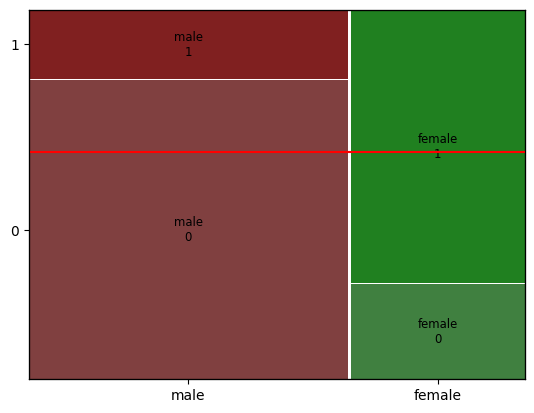

In [50]:
mosaic(titanic, [ 'Sex','Survived'])
plt.axhline(1- titanic['Survived'].mean(), color = 'r')
plt.show()

[문2] Embarked --> Survived

In [51]:
pd.crosstab(titanic['Survived'], titanic['Embarked'])

Embarked,C,Q,S
Survived,,,
0,75,47,427
1,93,30,217


In [52]:
pd.crosstab( titanic['Survived'], titanic['Embarked'], normalize = 'columns')

Embarked,C,Q,S
Survived,,,
0,0.446429,0.61039,0.663043
1,0.553571,0.38961,0.336957


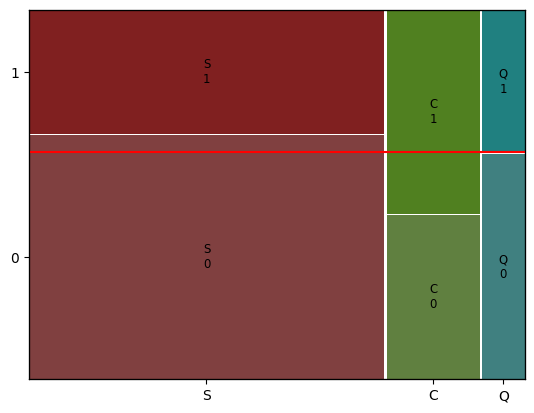

In [53]:
mosaic(titanic, [ 'Embarked','Survived'])
plt.axhline(1- titanic['Survived'].mean(), color = 'r')
plt.show()

[문3] Title --> Survived

In [54]:
pd.crosstab(titanic['Survived'], titanic['Title'], normalize = 'columns')

Title,Master,Miss,Mr,Mrs,Others
Survived,,,,,
0,0.425,0.302198,0.843327,0.208,0.555556
1,0.575,0.697802,0.156673,0.792,0.444444


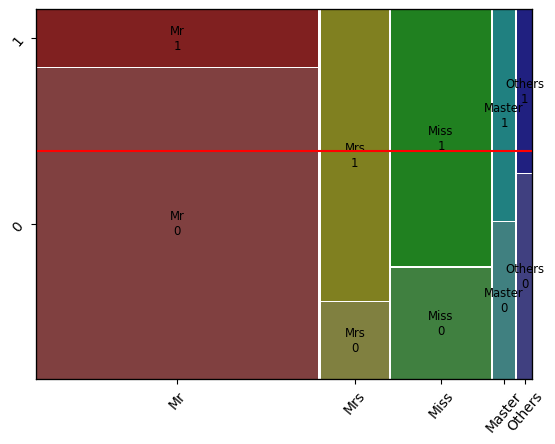

In [55]:
mosaic(titanic, ['Title','Survived'], label_rotation=50)
plt.axhline(1- titanic['Survived'].mean(), color = 'r')
plt.show()

### 4.2.3. 수치화 : 카이제곱검정

* 카이제곱검정 : 범주형 변수들 사이에 어떤 관계가 있는지, 수치화 하는 방법

- 카이 제곱 통계량
    - 계산 목적: 관측값(실제 데이터)과 기대값(관계가 없다고 가정했을 때의 값)의 차이를 측정하여, 두 범주형 변수 사이에 연관성이 있는지 확인함.
    - 클수록 기대빈도로부터 실제 값에 차이가 크다는 의미.
    - 계산식으로 볼 때, 범주의 수가 늘어날 수록 값은 커지게 되어 있음.
    - 보통, 자유도의 2~3배 보다 크면, 차이가 있다고 본다.

- 범주형 변수의 자유도 : 범주의 수 - 1

- 카이제곱검정에서는
    - x 변수의 자유도 × y 변수의 자유도
    - 예 : Pclass --> Survived
        - Pclass : 범주가 3개, Survived : 2개
        - (3-1) * (2-1) = 2
        - 그러므로, 2의 2 ~ 3배인 4 ~ 6 보다 카이제곱 통계량이 크면, 차이가 있다고 볼수 있음.


- 자유도 : https://blog.minitab.com/en/statistics-and-quality-data-analysis/what-are-degrees-of-freedom-in-statistics

* 타이타닉 데이터에서 객실등급과 생존여부 간의 카이제곱 검정을 수행해 봅시다.

In [56]:
table = pd.crosstab(titanic['Survived'], titanic['Pclass'])
display(table)

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


In [57]:
spst.chi2_contingency(table)

#output
# (카이제곱 통계량, p-value, 자유도, 기대빈도)

# 카이제곱 통계량: 기대빈도와 관측빈도 간의 차이를 측정한 값, 값이 클수록 두 변수 간에 연관성이 강하다는 것을 의미.
# 자유도 : Pclass 3개 범주, Survived 2개 범주 자유도 계산 => (3-1) * (2-1) = 2 (row행-1) * (col열-1) =

# 해석
# P-value: 매우 작아 귀무가설 (두 변수는 독립이다.)을 기각.
# 즉, 객실 등급과 생존 여부는 독립적이지 않고 서로 연관성이 있다.

Chi2ContingencyResult(statistic=np.float64(102.88898875696056), pvalue=np.float64(4.549251711298793e-23), dof=2, expected_freq=array([[133.09090909, 113.37373737, 302.53535354],
       [ 82.90909091,  70.62626263, 188.46464646]]))

**<연습문제>**

다음의 관계에 대해 수치화 해 봅시다.

[문1] Sex --> Survived

In [58]:
table = pd.crosstab(titanic['Survived'], titanic['Sex'])
display(table)

print('-' * 50)

spst.chi2_contingency(table)

Sex,female,male
Survived,,
0,81,468
1,233,109


--------------------------------------------------


Chi2ContingencyResult(statistic=np.float64(260.71702016732104), pvalue=np.float64(1.1973570627755645e-58), dof=1, expected_freq=array([[193.47474747, 355.52525253],
       [120.52525253, 221.47474747]]))

[문2] Embarked --> Survived

In [59]:
table = pd.crosstab(titanic['Survived'], titanic['Embarked'])
display(table)
print('-' * 50)


spst.chi2_contingency(table)

Embarked,C,Q,S
Survived,,,
0,75,47,427
1,93,30,217


--------------------------------------------------


Chi2ContingencyResult(statistic=np.float64(26.48914983923762), pvalue=np.float64(1.769922284120912e-06), dof=2, expected_freq=array([[103.7480315,  47.5511811, 397.7007874],
       [ 64.2519685,  29.4488189, 246.2992126]]))

[문3] Title --> Survived

In [60]:
table = pd.crosstab(titanic['Survived'], titanic['Title'])
display(table)
print('-' * 50)

spst.chi2_contingency(table)

Title,Master,Miss,Mr,Mrs,Others
Survived,,,,,
0,17,55,436,26,15
1,23,127,81,99,12


--------------------------------------------------


Chi2ContingencyResult(statistic=np.float64(283.3115089621979), pvalue=np.float64(4.305036064730923e-60), dof=4, expected_freq=array([[ 24.64646465, 112.14141414, 318.55555556,  77.02020202,
         16.63636364],
       [ 15.35353535,  69.85858586, 198.44444444,  47.97979798,
         10.36363636]]))

## 4.3.숫자 --> 범주

### 4.3.1. 시각화

- 시각화 : kde Plot, Histogram
    - 범주별 **분포**로 비교하는 그래프 그리기
    - 범주별 **비율**로 비교하는 그래프 그리기

* 히스토그램을 Survived로 나눠서 그려봅시다.

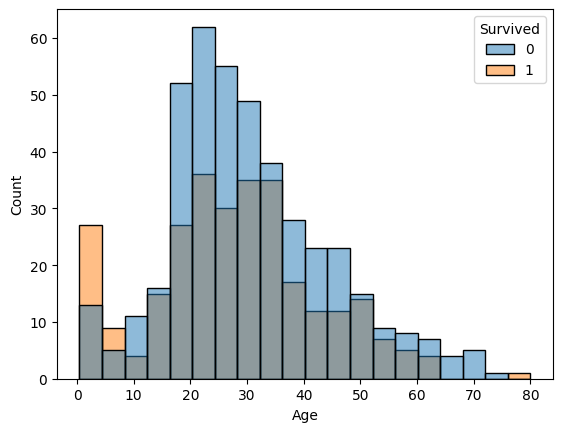

In [61]:
sns.histplot(x='Age', data=titanic, hue='Survived')
plt.show()

- kdeplot을 그리는 두 가지 방법이 있다.
    - ① kdeplot(   , hue = 'Survived')
        - 생존여부의 비율이 유지된 채로 그려짐
        - 두 그래프의 아래 면적의 합이 1
    - ② kdeplot(   , hue = 'Survived', common_norm = False)
        - 생존여부 각각 아래 면적의 합이 1인 그래프
    - ③ kdeplot(   , hue = 'Survived', multiple = 'fill')
        - 나이에 따라 생존여부 **비율**을 비교해볼 수 있음. (양의 비교가 아닌 비율!)


① kdeplot( , hue = 'Survived)
- common_norm = True (기본값)
    - common_norm: 그래프 안쪽 넓이가 True면 합쳐서 1, 아니면 각각 넓이가 1

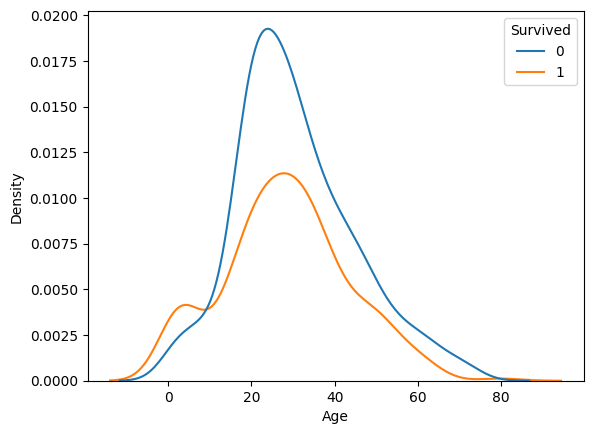

In [62]:
sns.kdeplot(x='Age', data=titanic, hue='Survived')
plt.show()

② kdeplot( , hue = 'Survived, common_norm = False)

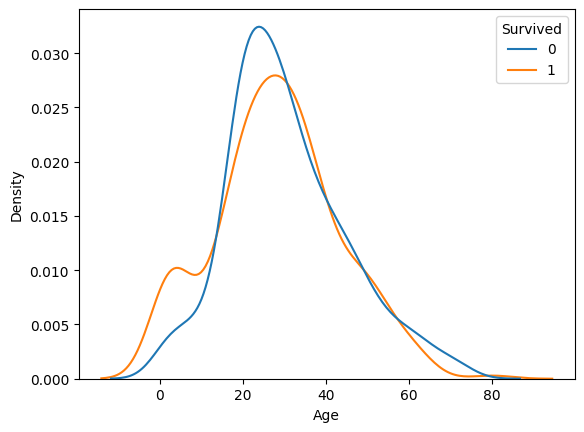

In [63]:
sns.kdeplot(x='Age', data=titanic, hue='Survived', common_norm=False)
plt.show()

③ multiple = 'fill' 옵션

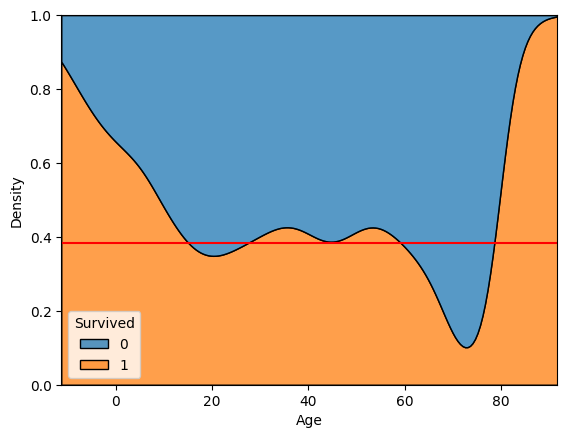

In [64]:
sns.kdeplot(x='Age',
            data=titanic,
            hue='Survived',
            multiple='fill')

plt.axhline(titanic['Survived'].mean(), color='r')
plt.show()

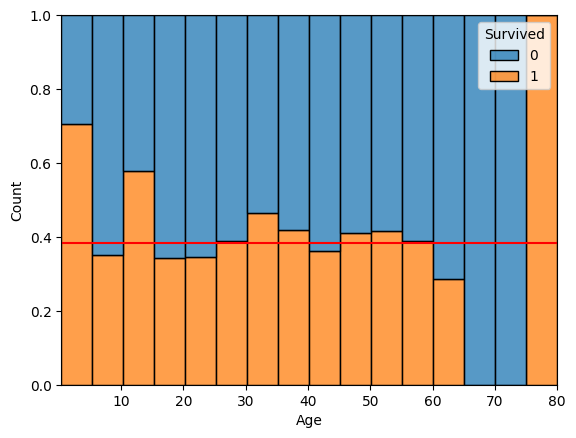

In [65]:
sns.histplot(x='Age',
            data=titanic,
            hue='Survived',
            bins=16,
            multiple='fill')

plt.axhline(titanic['Survived'].mean(), color='r')
plt.show()

- 나이에 따라서 생존여부가
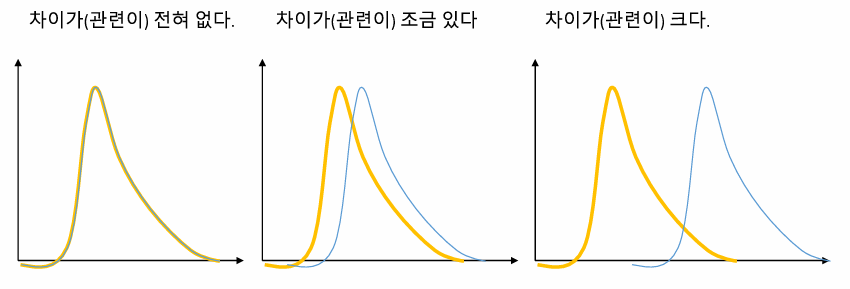

**<연습문제>**

다음의 관계에 대해 시각화 해 봅시다.

* [문1] Fare(운임) --> Survived

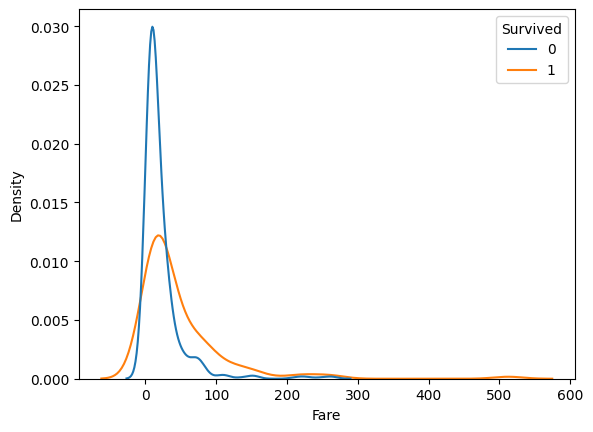

In [66]:
sns.kdeplot(x='Fare',
            data = titanic,
            hue ='Survived',
            common_norm = False)
plt.show()


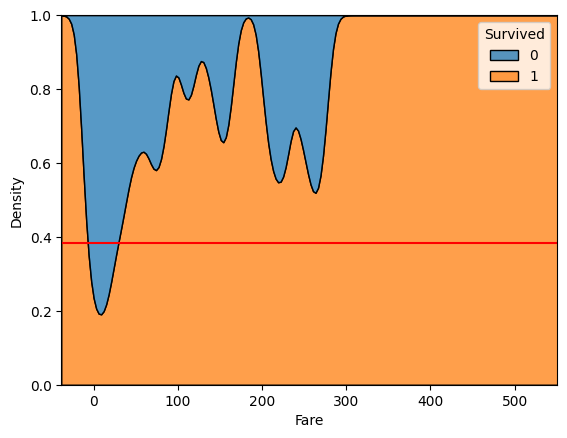

In [ ]:
sns.kdeplot(x='Fare',
            data = titanic,
            hue ='Survived',
            multiple = 'fill')

plt.axhline(titanic['Survived'].mean(), color = 'r')
plt.show()

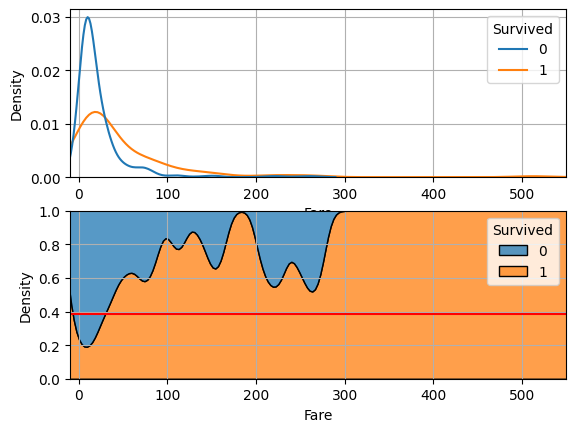

In [68]:
plt.subplot(2,1,1)
sns.kdeplot(x='Fare', data = titanic, hue ='Survived', common_norm=False)
plt.xlim(-10,550)   # 위아래 차트 x값 범위 맞추기
plt.grid()

plt.subplot(2,1,2)
sns.kdeplot(x='Fare', data = titanic, hue ='Survived', multiple = 'fill')
plt.axhline(titanic['Survived'].mean(), color = 'r')
plt.xlim(-10,550)
plt.grid()

plt.show()

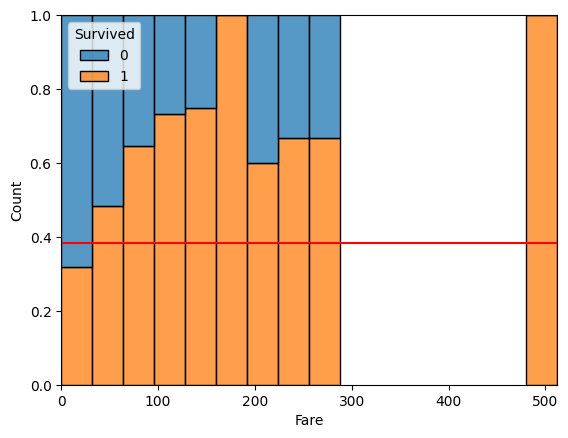

In [ ]:
sns.histplot(x='Fare',
             data = titanic,
             bins = 16,
            hue ='Survived',
            multiple = 'fill')

plt.axhline(titanic['Survived'].mean(), color = 'r')
plt.show()

<Axes: xlabel='Fare', ylabel='Count'>

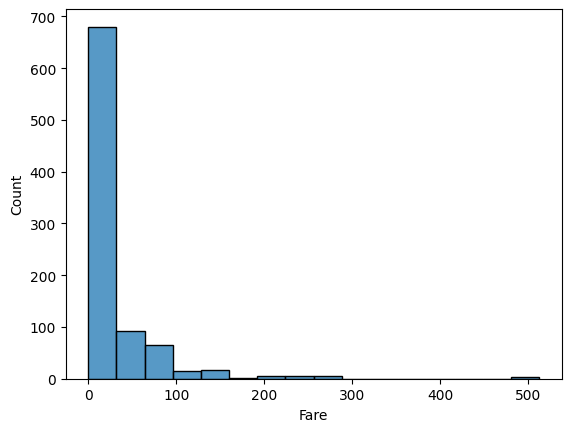

In [70]:
sns.histplot(x='Fare', data = titanic, bins = 16)